In [23]:
# import relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS

from sklearn.mixture import GaussianMixture

import warnings
warnings.filterwarnings('ignore')

# Get Data

In [24]:
# get data
sheet_name_list = ['Period 1', 'Period 2', 'Period 3']
data_list = []

for sheet_name in sheet_name_list:
    data_period = pd.read_excel('regime_data.xlsx', sheet_name=sheet_name).iloc[1:].copy()
    data_period = data_period.set_index('Unnamed: 0')
    data_period.index.name = 'DATE'
    data_period.columns.name = 'ID'
    data_list.append(data_period)

data_df = pd.concat(data_list, axis=0)
data_df = data_df.sort_index()
data_df

ID,MXCXDMHR Index,LGY7TRUH Index,LUACTRUU Index,LF98TRUU Index,LP05TRUH Index,LP01TRUH Index,BCOMTR Index,M1EF Index,EMUSTRUU Index,MXEF0CX0 Index,USDJPY BGN Curncy,USDCHF BGN Curncy,AUDUSD BGN Curncy,NZDUSD BGN Curncy,USDCAD BGN Curncy,EURUSD BGN Curncy,GBPUSD BGN Curncy,LBUTTRUU Index,SPY US Equity
DATE,,,,,,,,,,,,,,,,,,,
1970-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1970-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1970-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1970-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1970-01-05,NaN,NaN,NaN,NaN,NaN,NaN,3.1177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-27,713.99,846.9528,3555.1,2953.53,319.83,649.15,349.6279,894.06,1400.047,1874.5,159.42,0.7855,0.7186,0.5908,1.3627,1.1721,1.3535,378.3391,715.17
2026-04-28,710.84,846.1492,3552.86,2950.28,319.31,648.48,351.6852,886.9,1398.2716,1869.45,159.62,0.7893,0.7181,0.5885,1.3684,1.1712,1.3517,378.3211,711.69
2026-04-29,710.17,844.0966,3538.72,2945.34,318.6,648.07,357.2446,887.76,1396.1287,1866.59,160.41,0.7912,0.7116,0.5829,1.3685,1.1677,1.3475,377.1386,711.58


# Clean Data

In [25]:
### rename columns ###
# get data directory
data_dir = pd.read_csv('data_dir.csv')

# rename columns
ticker_to_label = data_dir.set_index("bbg_ticker")["secondary_label"].to_dict()
data_df = data_df.rename(columns=ticker_to_label)

### resample data and drop nan values ###
# start from 2022
# data_df = data_df.loc[pd.to_datetime("2002-01-02"):].dropna(how="all").ffill()

# get monthly data
data_df = data_df.resample("M").last().dropna()

data_df

ID,Equity,Rates,US IG,US HY,EU IG,EU HY,Commodities,EM Equity,EM Credit,EM Currency,USDJPY,USDCHF,AUDUSD,NZDUSD,USDCAD,EURUSD,GBPUSD,Local Inflation,Local Equity
DATE,,,,,,,,,,,,,,,,,,,
2000-12-31,117.58,305.2734,1089.65,517.12,109.29,102.60,184.9170,100.00,265.0728,793.51,114.41,1.6111,0.5588,0.4437,1.4991,0.9427,1.4930,122.9687,131.1875
2001-01-31,121.39,310.0040,1120.84,555.86,110.58,111.79,180.5730,113.76,277.2077,799.84,116.57,1.6354,0.5506,0.4439,1.4978,0.9366,1.4646,125.5350,137.0200
2001-02-28,111.99,313.7589,1130.31,563.26,111.05,112.53,179.8120,104.84,273.7935,794.84,117.37,1.6681,0.5263,0.4305,1.5364,0.9236,1.4455,127.6530,123.9500
2001-03-31,106.47,316.7754,1137.24,550.00,112.02,107.15,172.1510,94.50,270.8515,784.12,126.34,1.7428,0.4856,0.4029,1.5757,0.8767,1.4161,128.8739,116.6900
2001-04-30,113.84,314.0998,1133.53,543.15,111.20,104.05,178.2080,99.15,270.0810,791.33,123.48,1.7330,0.5124,0.4138,1.5350,0.8891,1.4320,129.6006,124.9100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-31,685.98,848.1162,3551.52,2929.32,321.16,647.55,304.8839,834.38,1391.8607,1863.38,154.78,0.7730,0.6964,0.6021,1.3613,1.1851,1.3686,373.7130,691.9700
2026-02-28,696.02,862.3596,3597.34,2934.74,323.59,649.94,308.2337,880.23,1408.8088,1883.91,156.05,0.7693,0.7118,0.5998,1.3640,1.1812,1.3482,378.5965,685.9900
2026-03-31,653.35,843.7389,3526.16,2900.04,316.42,635.31,343.6952,765.25,1368.1591,1831.75,158.72,0.7995,0.6900,0.5747,1.3916,1.1553,1.3227,373.5345,650.3400


In [26]:
### invert currency pairs ###
df_prices = data_df.copy()

# get fx pairs from data_dir
fx_pairs = data_dir.loc[
    data_dir["primary_label"].eq("FX"),
    "secondary_label"
].dropna().tolist()

# get fx pairs where USD is base ccy
fx_to_invert = [pair for pair in fx_pairs if pair.startswith("USD")]

# invert and rename ccy pair if USD is base ccy
rename_map = {}

for pair in fx_to_invert:
    if pair in df_prices.columns:
        df_prices[pair] = 1.0 / df_prices[pair]
        rename_map[pair] = pair[3:] + "USD"

df_prices = df_prices.rename(columns=rename_map)

df_prices.head()

ID,Equity,Rates,US IG,US HY,EU IG,EU HY,Commodities,EM Equity,EM Credit,EM Currency,JPYUSD,CHFUSD,AUDUSD,NZDUSD,CADUSD,EURUSD,GBPUSD,Local Inflation,Local Equity
DATE,,,,,,,,,,,,,,,,,,,
2000-12-31,117.58,305.2734,1089.65,517.12,109.29,102.60,184.917,100.00,265.0728,793.51,0.008740,0.620694,0.5588,0.4437,0.667067,0.9427,1.4930,122.9687,131.1875
2001-01-31,121.39,310.0040,1120.84,555.86,110.58,111.79,180.573,113.76,277.2077,799.84,0.008579,0.611471,0.5506,0.4439,0.667646,0.9366,1.4646,125.5350,137.0200
2001-02-28,111.99,313.7589,1130.31,563.26,111.05,112.53,179.812,104.84,273.7935,794.84,0.008520,0.599484,0.5263,0.4305,0.650872,0.9236,1.4455,127.6530,123.9500
2001-03-31,106.47,316.7754,1137.24,550.00,112.02,107.15,172.151,94.50,270.8515,784.12,0.007915,0.573789,0.4856,0.4029,0.634639,0.8767,1.4161,128.8739,116.6900
2001-04-30,113.84,314.0998,1133.53,543.15,111.20,104.05,178.208,99.15,270.0810,791.33,0.008098,0.577034,0.5124,0.4138,0.651466,0.8891,1.4320,129.6006,124.9100


# Get Factor Lens

In [27]:
# compute daily returns
returns_df = df_prices.pct_change().dropna(how='all')

returns_df.head()

ID,Equity,Rates,US IG,US HY,EU IG,EU HY,Commodities,EM Equity,EM Credit,EM Currency,JPYUSD,CHFUSD,AUDUSD,NZDUSD,CADUSD,EURUSD,GBPUSD,Local Inflation,Local Equity
DATE,,,,,,,,,,,,,,,,,,,
2001-01-31,0.032403,0.015496,0.028624,0.074915,0.011803,0.089571,-0.023492,0.137600,0.045779,0.007977,-0.018530,-0.014859,-0.014674,0.000451,0.000868,-0.006471,-0.019022,0.020870,0.044459
2001-02-28,-0.077436,0.012112,0.008449,0.013313,0.004250,0.006620,-0.004214,-0.078411,-0.012316,-0.006251,-0.006816,-0.019603,-0.044134,-0.030187,-0.025124,-0.013880,-0.013041,0.016872,-0.095388
2001-03-31,-0.049290,0.009614,0.006131,-0.023542,0.008735,-0.047809,-0.042606,-0.098626,-0.010745,-0.013487,-0.070999,-0.042862,-0.077332,-0.064111,-0.024941,-0.050780,-0.020339,0.009564,-0.058572
2001-04-30,0.069221,-0.008446,-0.003262,-0.012455,-0.007320,-0.028931,0.035184,0.049206,-0.002845,0.009195,0.023162,0.005655,0.055189,0.027054,0.026515,0.014144,0.011228,0.005639,0.070443
2001-05-31,-0.005534,0.005824,0.008875,0.018006,0.005216,0.015473,-0.020970,0.011599,0.025903,-0.001946,0.035645,-0.036098,-0.011514,-0.011358,-0.001951,-0.049263,-0.009497,0.011840,0.008326


In [ ]:
# initialize dictionary to store values
factor_dict = {}

# get primary macro factor returns
factor_dict['Equity'] = returns_df['Equity']
factor_dict['Rates'] = returns_df['Rates']

credit_cols = ['US IG', 'US HY', 'EU IG', 'EU HY']
factor_dict['Credit'] = returns_df[credit_cols].mean(axis=1)

factor_dict['Commodities'] = returns_df['Commodities']

# get secondary macro factor returns


In [45]:
# compute daily returns
returns_df = df_prices.pct_change()

# initialize dictionary to store values
factor_dict = {}

# single ticker factors
factor_dict['Equity'] = returns_df['MXCXDMHR Index']
factor_dict['Rates'] = returns_df['LGY7TRUH Index']
factor_dict['Commodities'] = returns_df['BCOMTR Index']
factor_dict['Local Inflation'] = returns_df['LBUTTRUU Index']
factor_dict['Local Equity'] = returns_df['SPY US Equity']

# credit factor
credit_tickers = ['LUACTRUU Index', 'LF98TRUU Index', 'LP05TRUH Index', 'LP01TRUH Index']
factor_dict['Credit'] = returns_df[credit_tickers].mean(axis=1)

# EM factor
em_tickers = ['M1EF Index', 'EMUSTRUU Index', 'MXEF0CX0 Index']
factor_dict['Emerging Market'] = returns_df[em_tickers].mean(axis=1)

# fx factirs
fx_tickers = [
    'USDJPY BGN Curncy', 'USDCHF BGN Curncy', 'USDCAD BGN Curncy',
    'AUDUSD BGN Curncy', 'NZDUSD BGN Curncy', 'EURUSD BGN Curncy', 'GBPUSD BGN Curncy'
]
factor_dict['Foreign Currency'] = returns_df[fx_tickers].mean(axis=1)

# create dataframe
factor_returns = pd.DataFrame(factor_dict).dropna(how='all')

# clean up dataframe
factor_returns = factor_returns.replace(0, np.nan).dropna()

factor_returns

,Equity,Rates,Commodities,Local Inflation,Local Equity,Credit,Emerging Market,Foreign Currency
DATE,,,,,,,,
2002-01-03,0.011652,0.001599,-0.002821,0.003564,0.011339,0.001329,0.007501,0.000731
2002-01-04,0.006775,-0.003532,0.020360,-0.001780,0.006676,0.000616,0.007968,-0.004083
2002-01-07,-0.005480,0.005089,0.010150,0.002715,-0.007057,0.008100,0.004884,0.002531
2002-01-08,-0.006863,-0.000315,-0.003075,0.000039,-0.002312,0.003722,-0.002786,-0.000243
2002-01-09,-0.003407,-0.001038,-0.005806,0.000423,-0.008153,0.001000,-0.000569,0.001717
...,...,...,...,...,...,...,...,...
2026-04-27,0.001641,-0.001750,0.008314,0.000067,0.001723,-0.000459,0.005017,-0.003687
2026-04-28,-0.004412,-0.000949,0.005884,-0.000048,-0.004866,-0.001097,-0.003990,0.002426
2026-04-29,-0.000943,-0.002426,0.015808,-0.003126,-0.000155,-0.002128,-0.000698,0.004612


# Orthogonalization

In [ ]:
# function to get 3 year rolling return
def get_pure_factor(target, independent_vars, df, window=36):
    Y = df[target]
    X = sm.add_constant(df[independent_vars])
    
    # Fit the rolling OLS model
    model = RollingOLS(Y, X, window=window).fit()
    
    # Calculate the pure factor (Y - Beta * X)
    betas = model.params.drop(columns=['const'])
    overlapping_risk = (df[independent_vars] * betas).sum(axis=1)
    
    pure_return = Y - overlapping_risk
    return pure_return

In [47]:
# get idiosyncratic risks for core macro (regress against equity and rates)
base_factors = ['Equity', 'Rates']
factor_returns['Credit_Pure'] = get_pure_factor('Credit', base_factors, factor_returns)
factor_returns['Commodities_Pure'] = get_pure_factor('Commodities', base_factors, factor_returns)

# get idiosyncratic risks for secondary macro (regress against all core macro)
all_core_factors = ['Equity', 'Rates', 'Credit_Pure', 'Commodities_Pure']
factor_returns['Emerging_Market_Pure'] = get_pure_factor('Emerging Market', all_core_factors, factor_returns)
factor_returns['Local_Inflation_Pure'] = get_pure_factor('Local Inflation', all_core_factors, factor_returns)
factor_returns['Foreign_Currency_Pure'] = get_pure_factor('Foreign Currency', all_core_factors, factor_returns)
factor_returns['Local_Equity_Pure'] = get_pure_factor('Local Equity', all_core_factors, factor_returns)

# filter for columsn contatining idiosyncratic risk
pure_cols = ['Equity', 'Rates', 'Credit_Pure', 'Commodities_Pure', 
             'Emerging_Market_Pure', 'Local_Inflation_Pure', 'Foreign_Currency_Pure', 'Local_Equity_Pure']

pure_factor_returns = factor_returns[pure_cols].dropna()

pure_factor_returns.head()

,Equity,Rates,Credit_Pure,Commodities_Pure,Emerging_Market_Pure,Local_Inflation_Pure,Foreign_Currency_Pure,Local_Equity_Pure
DATE,,,,,,,,
2002-01-03,0.011652,0.001599,0.001329,-0.002821,0.007501,0.003564,0.000731,0.011339
2002-01-04,0.006775,-0.003532,0.000616,0.020360,0.007968,-0.001780,-0.004083,0.006676
2002-01-07,-0.005480,0.005089,0.008100,0.010150,0.004884,0.002715,0.002531,-0.007057
2002-01-08,-0.006863,-0.000315,0.003722,-0.003075,-0.002786,0.000039,-0.000243,-0.002312
2002-01-09,-0.003407,-0.001038,0.001000,-0.005806,-0.000569,0.000423,0.001717,-0.008153


# GMM

In [48]:
split_date = '2020-01-01'
train_df = pure_factor_returns.loc[:split_date]
test_df = pure_factor_returns.loc[split_date:]

# get 2D array of features for model
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(train_df)

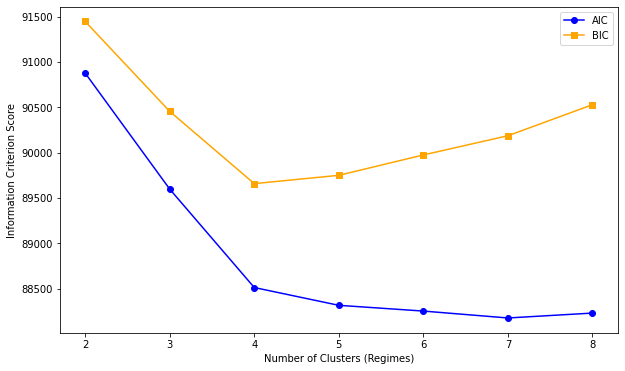

In [49]:
# tune hyperparameters
n_components_range = range(2, 9)

# initialise lists to store evaluation metrics
aic_scores = []
bic_scores = []

# train models and record scores
for n_clusters in n_components_range:
    gmm = GaussianMixture(n_components=n_clusters, 
                          covariance_type='full', 
                          random_state=42)

    gmm.fit(X_train)
    
    aic_scores.append(gmm.aic(X_train))
    bic_scores.append(gmm.bic(X_train))

# plot results
plt.figure(figsize=(10, 6))
plt.plot(n_components_range, aic_scores, label='AIC', marker='o', color='blue')
plt.plot(n_components_range, bic_scores, label='BIC', marker='s', color='orange')

plt.xlabel('Number of Clusters (Regimes)')
plt.ylabel('Information Criterion Score')
plt.legend()
plt.show()

In [50]:
# train model
optimal_clusters = 4

# fit model
final_gmm = GaussianMixture(n_components=optimal_clusters, 
                            covariance_type='full', 
                            random_state=42)

X = train_df.values
final_gmm.fit(X)

regime_predictions = final_gmm.predict(X)

# add regime into dataframe
train_df['Regime'] = regime_predictions

# get metrics
annualized_means = train_df.groupby('Regime').mean() * 252
annualized_vols = train_df.groupby('Regime').std() * np.sqrt(252)

In [51]:
print("\n--- ANNUALIZED MEAN RETURNS BY REGIME ---")
annualized_means.T


--- ANNUALIZED MEAN RETURNS BY REGIME ---


Regime,0,1,2,3
Equity,0.263929,-4.718876,4.171999,-0.728066
Rates,0.033257,0.289066,-0.189251,0.111194
Credit_Pure,0.061851,-0.211135,-0.370898,0.051881
Commodities_Pure,-0.044149,-0.533562,-0.486625,0.276949
Emerging_Market_Pure,-0.005822,0.215353,-0.067427,0.119227
Local_Inflation_Pure,-0.033628,-0.137293,-0.160301,0.128712
Foreign_Currency_Pure,0.025641,0.607072,-0.340053,-0.096754
Local_Equity_Pure,0.034970,-1.207101,1.503820,-0.160386


In [52]:
print("\n--- ANNUALIZED VOLATILITIES BY REGIME ---")
annualized_vols.T


--- ANNUALIZED VOLATILITIES BY REGIME ---


Regime,0,1,2,3
Equity,0.086572,0.337396,0.249458,0.192279
Rates,0.025370,0.063154,0.052829,0.035413
Credit_Pure,0.016873,0.074138,0.097707,0.029976
Commodities_Pure,0.123816,0.327207,0.209013,0.196270
Emerging_Market_Pure,0.042514,0.148735,0.126048,0.073056
Local_Inflation_Pure,0.033759,0.109004,0.108195,0.057404
Foreign_Currency_Pure,0.056368,0.130664,0.114011,0.086660
Local_Equity_Pure,0.049067,0.170804,0.251165,0.177247
